# 01. Deep Flow Prediction dataset preparation, V2

This notebook replaces the earlier preparation pipeline. It preserves the authors' input and target normalization for a direct comparison while correcting spatial layout, coordinate spacing, Reynolds metadata, split handling, and cache provenance.

Run this notebook before notebook 02. Both notebooks are self-contained. Use a **new prepared directory**; V1 caches and checkpoints have incompatible conventions.

**The original archive is required for research runs.** The default Colab location follows your earlier notebook. Edit the path cell if you moved the archive. A separate synthetic mode exists only to verify software.

| Issue in V1 | V2 behavior |
|---|---|
| Ambiguous spatial convention | Transpose original `[C,X,Y]` to `[C,Y,X]`, preserving velocity channel meanings |
| Endpoint-based grid spacing | Use the generator's spacing, `2/128` |
| Incorrect Reynolds estimate | Store `speed * 50_000` as the paper estimate; physical Reynolds number remains null unless viscosity is verified |
| Shared preprocessing statistics | Fit condition statistics on the selected training indices only |
| Reusable unversioned caches | Check schema, array and manifest hashes, raw identity and split provenance |
| Potential split leakage | Preserve the official test partition and audit airfoil identities and raster collisions |

**Purpose of the code.** Check dependencies, connect Colab Drive when applicable, and choose a new V2 project directory.

In [1]:
import os
import sys
from pathlib import Path
import importlib.util

if sys.version_info < (3, 12):
    raise RuntimeError('Use Python 3.12 or newer. This notebook was checked on Python 3.12.')
requirements = ['numpy', 'scipy', 'pandas', 'matplotlib']
missing = [name for name in requirements if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError('Install missing packages in this kernel: %pip install ' + ' '.join(missing))
IN_COLAB = 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))
if IN_COLAB and not os.environ.get('AIRFOIL_PROJECT_ROOT'):
    from google.colab import drive
    drive.mount('/content/drive')
DEFAULT_BASE = (Path('/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction')
                if IN_COLAB else Path.cwd())
PROJECT_ROOT = Path(os.environ.get('AIRFOIL_PROJECT_ROOT', str(DEFAULT_BASE/'rans_airfoil_project'/'publication_v2')))
SMOKE = os.environ.get('AIRFOIL_MODE', 'real') == 'smoke'
if SMOKE:
    PROJECT_ROOT = Path(os.environ.get('AIRFOIL_SMOKE_ROOT', '/tmp/airfoil_publication_v2_smoke'))
PREPARED_ROOT = PROJECT_ROOT/'prepared'
print('Project:', PROJECT_ROOT)
print('Mode:', 'SYNTHETIC SOFTWARE CHECK' if SMOKE else 'ORIGINAL CFD DATA')

Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2
Mode: ORIGINAL CFD DATA


## Select the original data

`ARCHIVE_PATH` should point to your original `data_6k.tar.gz`. Extraction creates a separate directory. If the original archive is already extracted elsewhere, set `RAW_ROOT` to the folder containing the `train` and `test` subdirectories. Do not point it at V1 processed arrays.

For the reduced dataset, the expected counts are 6,400 development samples and 90 test samples. Change `EXPECTED_TRAIN_SAMPLES` only when intentionally using a different documented original training archive.

**Purpose of the code.** Set data paths and explicitly separate estimated Reynolds labels from verified physical metadata.

In [2]:
ARCHIVE_PATH = Path(os.environ.get('AIRFOIL_ARCHIVE', str(DEFAULT_BASE/'data_6k.tar.gz')))
RAW_ROOT = Path(os.environ.get('AIRFOIL_RAW_ROOT', str(PROJECT_ROOT/'raw_original')))
EXPECTED_TRAIN_SAMPLES = 6400
EXPECTED_TEST_SAMPLES = 90
VERIFIED_NU = None                 # Only fill with archive-specific evidence, in m^2/s.
VISCOSITY_EVIDENCE = None          # Required if VERIFIED_NU is provided.
CHORD = 1.0
SPLIT_SEED = 31415
print('Archive:', ARCHIVE_PATH)
print('Raw root:', RAW_ROOT)
print('Prepared root:', PREPARED_ROOT)

Archive: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/data_6k.tar.gz
Raw root: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/raw_original
Prepared root: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/prepared


## Preparation implementation

The original channels are freestream x, freestream y, solid mask, kinematic pressure, velocity x, and velocity y. Stored targets use `[u,v,p]`. For the historical comparison, pressure is centered over all original pixels and then zeroed inside the solid. Velocities are divided by freestream speed; pressure is divided by speed squared. The fixed target maxima are `[2.04, 2.37, 4.65]` in the new channel order.

The SDF and surface directions are derived solely from the input mask. They never use target velocity or pressure. Raster normals are approximate geometric features.

**Purpose of the code.** Define auditable loading, preprocessing, identity checks, and deterministic splits. Implementation block 1.

In [3]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import re
import shutil
import tarfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, binary_erosion, binary_dilation

SCHEMA_VERSION = 'dfp-publication-v2.0'
ORIGINAL_COMMIT = '8a5efa4'
TARGET_SCALES = np.array([2.04, 2.37, 4.65], dtype=np.float32)  # u, v, kinematic p
INPUT_SCALES = np.array([100.0, 38.12], dtype=np.float32)


def json_hash(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False))
    temporary.replace(path)


def read_json(path):
    return json.loads(Path(path).read_text())


def original_coordinates(size=128):
    # The generator samples endpoints with i/res, not i/(res-1).
    x = -0.5 + 2.0 * np.arange(size, dtype=np.float64) / size
    y = -1.0 + 2.0 * np.arange(size, dtype=np.float64) / size
    xx, yy = np.meshgrid(x, y, indexing='xy')
    return xx.astype(np.float32), yy.astype(np.float32), 2.0 / size


def group_from_filename(path):
    # Original files end in two signed integer velocity components.
    match = re.fullmatch(r'(.+)_(-?\d+)_(-?\d+)', Path(path).stem)
    if match is None:
        raise ValueError(f'Cannot infer airfoil identity from {Path(path).name}. Supply original filenames.')
    return match.group(1).casefold()


def extract_archive_safely(archive, destination):
    archive, destination = Path(archive), Path(destination)
    digest = sha256_file(archive)
    marker = destination / 'archive_receipt.json'
    if marker.exists():
        if read_json(marker)['archive_sha256'] != digest:
            raise ValueError('Extraction directory belongs to a different archive. Use a new directory.')
        return destination
    if destination.exists() and any(destination.iterdir()):
        raise ValueError('Use an empty extraction directory or an existing verified extraction.')
    destination.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive, 'r:*') as stream:
        members = stream.getmembers()
        root = destination.resolve()
        for member in members:
            resolved = (root / member.name).resolve()
            if not resolved.is_relative_to(root) or member.issym() or member.islnk():
                raise ValueError(f'Unsafe archive member: {member.name}')
            if not (member.isfile() or member.isdir()):
                raise ValueError(f'Unsupported archive member: {member.name}')
        stream.extractall(root, members=members, filter='data')
    write_json(marker, {'archive_sha256': digest, 'archive_name': archive.name})
    return destination


def discover_original_files(raw_root):
    train, test = [], []
    for path in sorted(Path(raw_root).rglob('*.npz')):
        # Exact path components prevent 'training_project/test' being classified twice.
        parts = [p.casefold() for p in path.relative_to(raw_root).parts[:-1]]
        if 'train' in parts and 'test' in parts:
            raise ValueError(f'Ambiguous split: {path}')
        if 'train' in parts:
            train.append(path)
        elif 'test' in parts:
            test.append(path)
    if not train or not test:
        raise FileNotFoundError('Expected original train/*.npz and test/*.npz under RAW_ROOT.')
    return train, test


def read_original_sample(path, verified_nu=None, chord=1.0):
    with np.load(path, allow_pickle=False) as archive:
        if 'a' not in archive.files:
            raise ValueError(f'{path}: expected original NPZ key a.')
        raw = np.asarray(archive['a'], dtype=np.float64)
    if raw.shape != (6, 128, 128) or not np.isfinite(raw).all():
        raise ValueError(f'{path}: expected finite [6,128,128] original data.')
    # Transpose SPATIAL axes only. Velocity channel meanings remain unchanged.
    a = raw.transpose(0, 2, 1).copy()
    solid = a[2] > 0.5
    if not np.isin(a[2], [0, 1]).all() or solid.sum() == 0 or (~solid).sum() == 0:
        raise ValueError(f'{path}: invalid solid mask.')
    fluid = ~solid
    fs = np.array([np.median(a[0][fluid]), np.median(a[1][fluid])])
    U = float(np.linalg.norm(fs))
    if U <= 0 or not all(np.allclose(a[k], fs[k] * fluid, atol=1e-5) for k in [0, 1]):
        raise ValueError(f'{path}: inconsistent freestream channels.')
    if not (9.9 <= U <= 100.1):
        raise ValueError('Raw speed outside the original 10-100 range. Do not pass normalized arrays.')
    # EXACT legacy transformation: mean over ALL pixels, then zero solid pressure.
    p = (a[3] - a[3].mean()) * fluid
    star = np.stack([a[4] / U, a[5] / U, p / (U * U)])
    legacy = (star / TARGET_SCALES[:, None, None]).astype(np.float32)
    xx, yy, spacing = original_coordinates(128)
    sdf = (distance_transform_edt(fluid, sampling=spacing)
           - distance_transform_edt(solid, sampling=spacing)).astype(np.float32)
    input_hash = hashlib.sha256(np.ascontiguousarray(raw[:3]).tobytes()).hexdigest()
    mask_hash = hashlib.sha256(np.ascontiguousarray(solid).tobytes()).hexdigest()
    row = {
        'sample_id': Path(path).stem,
        'airfoil_id': group_from_filename(path),
        'source_path': str(Path(path).resolve()),
        'source_sha256': sha256_file(path),
        'input_sha256': input_hash,
        'mask_sha256': mask_hash,
        'u_inf': float(fs[0]), 'v_inf': float(fs[1]), 'speed': U,
        'flow_angle_deg': float(np.degrees(np.arctan2(fs[1], fs[0]))),
        're_paper_estimate': U * 50_000.0,
        're_physical': None if verified_nu is None else U * chord / verified_nu,
    }
    return legacy, solid.astype(np.uint8), sdf, row

**Purpose of the code.** Define auditable loading, preprocessing, identity checks, and deterministic splits. Implementation block 2.

In [4]:
def prepare_original_dataset(raw_root, output_root, verified_nu=None,
                             viscosity_evidence=None, chord=1.0, synthetic=False):
    output_root = Path(output_root)
    if verified_nu is not None and (verified_nu <= 0 or not viscosity_evidence):
        raise ValueError('Verified positive viscosity requires a provenance note.')
    if output_root.exists() and any(output_root.iterdir()):
        raise FileExistsError('Prepared directory already exists. Use a new versioned directory.')
    train, test = discover_original_files(raw_root)
    settings = {
        'schema': SCHEMA_VERSION, 'source_layout': 'CXY', 'prepared_layout': 'CYX',
        'size': 128, 'dx': 2 / 128, 'dy': 2 / 128,
        'x_origin': -0.5, 'y_origin': -1.0, 'chord': chord,
        'pressure_units': 'kinematic pressure; m^2/s^2',
        'target_order': ['u', 'v', 'p'],
        'normalization': 'legacy_all_pixel_pressure_gauge_then_fixed_maxima',
        'target_scales': TARGET_SCALES.tolist(), 'input_scales': INPUT_SCALES.tolist(),
        'verified_nu': verified_nu, 'viscosity_evidence': viscosity_evidence,
        're_status': 'paper mapping is estimated; physical Re null without verified viscosity',
        'synthetic': bool(synthetic), 'original_commit': ORIGINAL_COMMIT,
    }
    manifest = []
    try:
        for split, files in [('train', train), ('test', test)]:
            folder = output_root / split
            folder.mkdir(parents=True)
            target = np.lib.format.open_memmap(folder / 'target_legacy.npy', mode='w+',
                dtype=np.float32, shape=(len(files), 3, 128, 128))
            masks = np.lib.format.open_memmap(folder / 'solid.npy', mode='w+',
                dtype=np.uint8, shape=(len(files), 128, 128))
            sdfs = np.lib.format.open_memmap(folder / 'sdf.npy', mode='w+',
                dtype=np.float32, shape=(len(files), 128, 128))
            for i, path in enumerate(files):
                target[i], masks[i], sdfs[i], row = read_original_sample(path, verified_nu, chord)
                row.update(split=split, index=i)
                manifest.append(row)
                if (i + 1) % 500 == 0:
                    print(f'{split}: {i + 1}/{len(files)}')
            target.flush(); masks.flush(); sdfs.flush()
            del target, masks, sdfs
        table = pd.DataFrame(manifest)
        if table['sample_id'].duplicated().any() or table['input_sha256'].duplicated().any():
            raise ValueError('Duplicate sample identity or identical inputs detected. Audit before training.')
        tr, te = table[table.split == 'train'], table[table.split == 'test']
        overlap = sorted(set(tr.airfoil_id) & set(te.airfoil_id))
        if overlap:
            raise ValueError(f'Train/test airfoil identity overlap: {overlap[:8]}')
        raster_overlap = sorted(set(tr.mask_sha256) & set(te.mask_sha256))
        table.to_csv(output_root / 'manifest.csv', index=False)
        hashes = {str(p.relative_to(output_root)): sha256_file(p)
                  for p in sorted(output_root.rglob('*.npy'))}
        identity = json_hash({'settings': settings, 'manifest': manifest, 'arrays': hashes})
        metadata = {'settings': settings, 'dataset_id': identity, 'array_sha256': hashes,
                    'manifest_sha256': sha256_file(output_root / 'manifest.csv'),
                    'train_samples': len(train), 'test_samples': len(test),
                    'test_airfoils': int(te.airfoil_id.nunique()),
                    'raster_overlap_count': len(raster_overlap),
                    'raster_overlap_note': 'Report raster collisions; do not silently alter the official benchmark.'}
        write_json(output_root / 'metadata.json', metadata)
        return metadata
    except Exception:
        # Preserve partial files for diagnosis; metadata.json is the completion receipt.
        raise


def verify_prepared_dataset(root, full_hash_check=False):
    root = Path(root)
    meta = read_json(root / 'metadata.json')
    if meta['settings']['schema'] != SCHEMA_VERSION:
        raise ValueError('Prepared schema mismatch. Rerun preparation notebook V2.')
    if sha256_file(root / 'manifest.csv') != meta['manifest_sha256']:
        raise ValueError('Prepared manifest changed.')
    if full_hash_check:
        for name, digest in meta['array_sha256'].items():
            if sha256_file(root / name) != digest:
                raise ValueError(f'Prepared array changed: {name}')
    return meta


def create_split(root, protocol='official_random', seed=31415):
    meta = verify_prepared_dataset(root)
    table = pd.read_csv(Path(root) / 'manifest.csv')
    table = table[table.split == 'train'].reset_index(drop=True)
    rng = np.random.default_rng(seed)
    n_val = max(1, min(400, int(len(table) * 0.2)))
    if protocol == 'official_random':
        val = sorted(rng.permutation(len(table))[:n_val].tolist())
    elif protocol == 'geometry_validation':
        # Group on raster identity too: union airfoil IDs that have equal masks.
        parent = {x: x for x in table.airfoil_id.unique()}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        for _, group in table.groupby('mask_sha256'):
            ids = group.airfoil_id.unique()
            for g in ids[1:]:
                parent[find(g)] = find(ids[0])
        components = table.airfoil_id.map(find)
        ordered = rng.permutation(sorted(components.unique()))
        val = []
        for g in ordered:
            val.extend(np.flatnonzero(components.to_numpy() == g).tolist())
            if len(val) >= n_val:
                break
        val = sorted(val)
    elif protocol in ['speed_extrapolation', 'angle_extrapolation']:
        values = table.speed.to_numpy() if protocol == 'speed_extrapolation' else np.abs(table.flow_angle_deg.to_numpy())
        threshold = 80.0 if protocol == 'speed_extrapolation' else 15.0
        val = np.flatnonzero(values > threshold).tolist()
    else:
        raise ValueError(protocol)
    train = sorted(set(range(len(table))) - set(val))
    if len(train) < 2 or not val:
        raise ValueError('Split too small for training and validation.')
    result = {'dataset_id': meta['dataset_id'], 'protocol': protocol, 'split_seed': seed,
              'train_indices': train, 'val_indices': val,
              'note': 'Fixed reconstructed split, not the unavailable authors original randomized sample list.'}
    result['split_id'] = json_hash(result)
    write_json(Path(root) / 'splits' / f'{protocol}_{seed}.json', result)
    return result

**Purpose of the code.** Define auditable loading, preprocessing, identity checks, and deterministic splits. Implementation block 3.

In [5]:
def fit_condition_stats(root, split):
    table = pd.read_csv(Path(root) / 'manifest.csv')
    table = table[table.split == 'train'].reset_index(drop=True).iloc[split['train_indices']]
    values = np.stack([table.u_inf / table.speed, table.v_inf / table.speed,
                       np.log(table.speed / 10.0)], axis=1).astype(np.float64)
    return {'mean': values.mean(0).tolist(), 'std': np.maximum(values.std(0), 1e-6).tolist(),
            'split_id': split['split_id'], 'features': ['flow_cos', 'flow_sin', 'log_speed_over_10'],
            'target_statistics': 'Fixed original maxima; no fitted target statistics.'}


def make_synthetic_original_dataset(root, train_groups=6, test_groups=2):
    # Integration fixture only. These are NOT CFD solutions and cannot support results.
    root = Path(root)
    xx, yy, _ = original_coordinates()
    for split, groups, offset in [('train', train_groups, 0), ('test', test_groups, 100)]:
        (root / split).mkdir(parents=True, exist_ok=True)
        for g in range(groups):
            index = g + offset
            thickness = 0.04 + 0.003 * (index % 20)
            camber = (index % 7 - 3) * 0.004
            solid = ((xx - 0.5) / 0.5) ** 2 + ((yy - camber) / thickness) ** 2 < 1
            fluid = ~solid
            for k, angle in enumerate([-8.0, 6.0, 18.0]):
                U = 20.0 + 12 * k + (g % 3)
                theta = np.radians(angle)
                fsx, fsy = U * np.cos(theta), U * np.sin(theta)
                wake = np.exp(-((yy - camber - 0.15 * (xx - 1)) / 0.12) ** 2) * np.clip(xx - 0.8, 0, 1)
                p = -0.1 * U**2 * np.exp(-((xx - .4)**2 + yy**2) / .05) * fluid
                u = fsx * (1 - 0.25 * wake) * fluid
                v = (fsy + 0.1 * U * wake) * fluid
                a = np.stack([fsx * fluid, fsy * fluid, solid, p, u, v]).transpose(0, 2, 1)
                np.savez_compressed(root / split / f'synthetic{index:03d}_{int(fsx*100)}_{int(fsy*100)}.npz', a=a)
    return root

**Purpose of the code.** Prepare the original archive, or a clearly labeled synthetic fixture, and verify the resulting data.

In [6]:
if (PREPARED_ROOT/'metadata.json').exists():
    metadata = verify_prepared_dataset(PREPARED_ROOT, full_hash_check=True)
    if bool(metadata['settings']['synthetic']) != SMOKE:
        raise ValueError('This directory belongs to a different data mode. Select a new directory.')
else:
    if SMOKE:
        RAW_ROOT = make_synthetic_original_dataset(PROJECT_ROOT/'raw_synthetic')
    elif not RAW_ROOT.exists():
        if not ARCHIVE_PATH.is_file():
            raise FileNotFoundError(f'Original archive not found: {ARCHIVE_PATH}. Set ARCHIVE_PATH or RAW_ROOT.')
        extract_archive_safely(ARCHIVE_PATH, RAW_ROOT)
    metadata = prepare_original_dataset(RAW_ROOT, PREPARED_ROOT,
        verified_nu=VERIFIED_NU, viscosity_evidence=VISCOSITY_EVIDENCE,
        chord=CHORD, synthetic=SMOKE)
if not SMOKE:
    if EXPECTED_TRAIN_SAMPLES is not None and metadata['train_samples'] != EXPECTED_TRAIN_SAMPLES:
        raise ValueError(f"Expected {EXPECTED_TRAIN_SAMPLES} train samples, found {metadata['train_samples']}. Audit the archive.")
    if metadata['test_samples'] != EXPECTED_TEST_SAMPLES or metadata['test_airfoils'] != 30:
        raise ValueError('Expected the original 90 tests on 30 held-out airfoils.')
print(json.dumps(metadata, indent=2))

train: 500/6400
train: 1000/6400
train: 1500/6400
train: 2000/6400
train: 2500/6400
train: 3000/6400
train: 3500/6400
train: 4000/6400
train: 4500/6400
train: 5000/6400
train: 5500/6400
train: 6000/6400
{
  "settings": {
    "schema": "dfp-publication-v2.0",
    "source_layout": "CXY",
    "prepared_layout": "CYX",
    "size": 128,
    "dx": 0.015625,
    "dy": 0.015625,
    "x_origin": -0.5,
    "y_origin": -1.0,
    "chord": 1.0,
    "pressure_units": "kinematic pressure; m^2/s^2",
    "target_order": [
      "u",
      "v",
      "p"
    ],
    "normalization": "legacy_all_pixel_pressure_gauge_then_fixed_maxima",
    "target_scales": [
      2.0399999618530273,
      2.369999885559082,
      4.650000095367432
    ],
    "input_scales": [
      100.0,
      38.119998931884766
    ],
    "verified_nu": null,
    "viscosity_evidence": null,
    "re_status": "paper mapping is estimated; physical Re null without verified viscosity",
    "synthetic": false,
    "original_commit": "8a5efa4

**Purpose of the code.** Create a fixed historical-style development split and a separate grouped geometry validation split.

In [7]:
official_split = create_split(PREPARED_ROOT, 'official_random', SPLIT_SEED)
geometry_split = create_split(PREPARED_ROOT, 'geometry_validation', SPLIT_SEED)
condition_stats = fit_condition_stats(PREPARED_ROOT, official_split)
write_json(PREPARED_ROOT/'splits'/f'condition_stats_official_random_{SPLIT_SEED}.json', condition_stats)
display(pd.DataFrame([
    {'protocol': s['protocol'], 'train': len(s['train_indices']), 'validation': len(s['val_indices']),
     'official_test': metadata['test_samples'], 'split_id': s['split_id'][:12]}
    for s in [official_split, geometry_split]
]))
print('Raster collisions across original train/test partitions:', metadata['raster_overlap_count'])
print('The reconstructed split is reproducible; the authors original randomized indices are unavailable.')

,protocol,train,validation,official_test,split_id
0,official_random,6000,400,90,78959e9a5d58
1,geometry_validation,5999,401,90,cb1f37919afa


Raster collisions across original train/test partitions: 1
The reconstructed split is reproducible; the authors original randomized indices are unavailable.


## Training-only visual audit

This preview checks orientation, geometry, scaling, and freestream metadata on a training sample. It does not inspect official test predictions. A fluid pixel adjacent to the rasterized surface is not the exact no-slip wall. Crop edges are not the farfield boundary of the original CFD domain.

**Purpose of the code.** Inspect one training case in physical coordinates and record preparation completion.

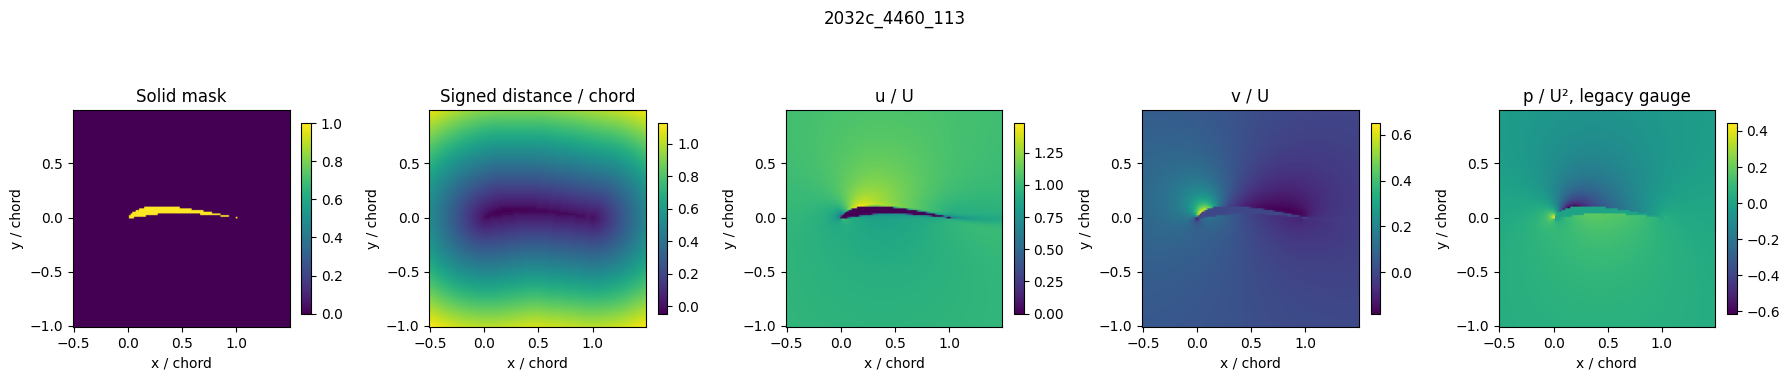

,sample_id,speed,flow_angle_deg,re_paper_estimate,re_physical
0,2032c_4460_113,44.619762,1.453722,2.230988e+06,NaN


Preparation complete. Open notebook 02 with the same PROJECT_ROOT.


In [8]:
manifest = pd.read_csv(PREPARED_ROOT/'manifest.csv')
training_manifest = manifest[manifest.split == 'train'].reset_index(drop=True)
index = official_split['train_indices'][0]
target = np.load(PREPARED_ROOT/'train'/'target_legacy.npy', mmap_mode='r')[index]
solid = np.load(PREPARED_ROOT/'train'/'solid.npy', mmap_mode='r')[index]
sdf = np.load(PREPARED_ROOT/'train'/'sdf.npy', mmap_mode='r')[index]
star = target * TARGET_SCALES[:, None, None]
xx, yy, spacing = original_coordinates()
extent = (float(xx.min()-spacing/2), float(xx.max()+spacing/2),
          float(yy.min()-spacing/2), float(yy.max()+spacing/2))
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fields = [solid, sdf, star[0], star[1], star[2]]
names = ['Solid mask', 'Signed distance / chord', 'u / U', 'v / U', 'p / U², legacy gauge']
for ax, field, name in zip(axes, fields, names):
    im = ax.imshow(field, origin='lower', extent=extent, cmap='viridis')
    ax.set_title(name); ax.set_xlabel('x / chord'); ax.set_ylabel('y / chord')
    fig.colorbar(im, ax=ax, fraction=.04)
fig.suptitle(('SYNTHETIC SOFTWARE FIXTURE: ' if SMOKE else '') + training_manifest.iloc[index].sample_id)
fig.tight_layout(); plt.show()
display(training_manifest.iloc[[index]][['sample_id','speed','flow_angle_deg','re_paper_estimate','re_physical']])
write_json(PROJECT_ROOT/'preparation_complete.json', {'dataset_id': metadata['dataset_id'],
    'prepared_root': str(PREPARED_ROOT.resolve()), 'synthetic': SMOKE,
    'official_split_id': official_split['split_id'], 'geometry_split_id': geometry_split['split_id']})
print('Preparation complete. Open notebook 02 with the same PROJECT_ROOT.')

In [9]:
metadata_path = PREPARED_ROOT / 'metadata.json'
if metadata_path.exists():
    print(f"SUCCESS: Found metadata.json at: {metadata_path}")
    # Display the file size and last modified time to be sure
    stat = metadata_path.stat()
    print(f"Size: {stat.st_size} bytes")
else:
    print(f"FAILURE: metadata.json NOT found in {PREPARED_ROOT}")
    print("Current directory contents:")
    display(os.listdir(PREPARED_ROOT))

SUCCESS: Found metadata.json at: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/prepared/metadata.json
Size: 1755 bytes


## Sources and limits of the contribution

* Thuerey et al., [Deep Learning Methods for Reynolds-Averaged Navier-Stokes Simulations of Airfoil Flows](https://arxiv.org/abs/1810.08217), provided version 3. The released experiment uses a cropped Cartesian sampling of RANS solutions, not the full solver mesh.
* [Historical network](https://github.com/thunil/Deep-Flow-Prediction/blob/8a5efa4/train/DfpNet.py), [normalization](https://github.com/thunil/Deep-Flow-Prediction/blob/8a5efa4/train/dataset.py), and [evaluation](https://github.com/thunil/Deep-Flow-Prediction/blob/8a5efa4/train/runTest.py). The embedded generator retains its original attribution. The surrounding workflow is revised; the unused discriminator is omitted.
* [Generator sampling coordinates](https://github.com/thunil/Deep-Flow-Prediction/blob/master/data/utils.py) and [repository viscosity](https://github.com/thunil/Deep-Flow-Prediction/blob/master/data/OpenFOAM/constant/transportProperties). The paper's Reynolds mapping and the visible repository viscosity are not sufficient to establish the exact viscosity used for every archived sample.
* [U-FNO](https://arxiv.org/abs/2109.03697), [Geo-FNO](https://arxiv.org/abs/2207.05209), [GINO](https://arxiv.org/abs/2309.00583), and [geometry-aware airfoil prediction using coordinate transformations](https://arxiv.org/abs/2109.02183) establish relevant prior work. Adding Fourier layers, an SDF, or a U-Net is not by itself a novelty claim.
* Related [SDF derivative constraints](https://arxiv.org/abs/2503.17289) and [DD-RNO](https://arxiv.org/abs/2608.13490) must also be considered when positioning geometry and regional processing. This release does not claim to be the first such method.

The research hypothesis is that adaptive local feature differences, sampled along flow and surface directions and iterated after a multiscale spectral prediction, improve airfoil prediction at a useful cost. The included ablations can test that hypothesis. Originality still requires a focused comparison with current work. Generalization beyond this fixed raster dataset, drag accuracy, and resolution-independent operator learning are not established here.